In [116]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import joblib
import os
from finance_util import calculate_technical_indicators
from datetime import datetime, timedelta, date

# Load saved objects from the specified folder
save_dir = 'model/output'
model_dir = 'model/pca'
scaler = joblib.load(os.path.join(model_dir, 'scaler.pkl'))
pca = joblib.load(os.path.join(model_dir, 'pca.pkl'))
feature_names = joblib.load(os.path.join(model_dir, 'feature_names.pkl'))
models = [joblib.load(os.path.join(model_dir, f'model_day_{i + 1}.pkl')) for i in range(14)]

# Define new stock and dates
new_ticker = 'ORCL'  # Example: Tesla
end_date = '2025-02-23'
today = date.today()
end_date = today.strftime("%Y-%m-%d")
print(f"end_date : {end_date}")
start_date = (datetime.strptime(end_date, '%Y-%m-%d') - timedelta(days=60)).strftime('%Y-%m-%d')

# Download data for new stock
new_data = yf.download(new_ticker, start=start_date, end=end_date)

# Calculate technical indicators
new_data = calculate_technical_indicators(new_data)
selected_cols = ['Return', '20d_MA', '50d_MA', '20d_Volatility', 'Upper_BB', 'Lower_BB', 'RSI', 'MACD', 'Signal_Line', 'OBV', 'ATR', 'Williams_%R']
new_features = new_data[selected_cols]
new_features.columns = [f'{new_ticker}_{col}' for col in new_features.columns]

# Align features with training data
seq_length = 20
latest_features = new_features.tail(seq_length).copy()
for col in feature_names:
    if col not in latest_features.columns:
        latest_features[col] = 0
latest_features = latest_features[feature_names]
latest_features = latest_features.fillna(0)

# Preprocess new data
latest_flat = latest_features.values.flatten().reshape(1, -1)
latest_scaled = scaler.transform(latest_flat)
latest_pca = pca.transform(latest_scaled)

# Predict 14-day returns
predicted_returns = [float(model.predict(latest_pca)[0]) for model in models]  # Ensure scalar float

# Calculate volatility
volatility = new_data['Return'].std()

# Get current price (fix FutureWarning)
current_price = new_data['Close'].iloc[-1]  # Directly get scalar value

# Forecast prices
forecast_dates = pd.date_range(start=end_date, periods=15)[1:]
forecast_prices = [current_price]
forecast_lows = [current_price]
forecast_highs = [current_price]

for i in range(14):
    daily_return = predicted_returns[i]
    next_price = forecast_prices[-1] * (1 + daily_return / 100)
    daily_vol = volatility * forecast_prices[-1] / 100
    forecast_prices.append(next_price)
    forecast_lows.append(next_price - daily_vol)
    forecast_highs.append(next_price + daily_vol)

# Create forecast DataFrame with numeric formatting
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Symbol': new_ticker,
    'Predicted_Price': forecast_prices[1:],
    'Low': forecast_lows[1:],
    'High': forecast_highs[1:]
})
forecast_df['Predicted_Price'] = forecast_df['Predicted_Price'].astype(float).round(2)
forecast_df['Low'] = forecast_df['Low'].astype(float).round(2)
forecast_df['High'] = forecast_df['High'].astype(float).round(2)

print(f"\n{new_ticker} 14-Day Price Forecast:")
print(forecast_df.to_string(index=False))
forecast_df.to_csv(f"{save_dir}/{new_ticker}_{end_date}.csv", index=False)

[*********************100%***********************]  1 of 1 completed

end_date : 2025-02-25

ORCL 14-Day Price Forecast:
      Date Symbol  Predicted_Price    Low   High
2025-02-26   ORCL           173.39 167.46 179.32
2025-02-27   ORCL           174.08 168.03 180.13
2025-02-28   ORCL           171.07 165.00 177.14
2025-03-01   ORCL           171.91 165.94 177.88
2025-03-02   ORCL           171.04 165.04 177.04
2025-03-03   ORCL           171.96 165.99 177.93
2025-03-04   ORCL           173.05 167.05 179.05
2025-03-05   ORCL           174.30 168.26 180.33
2025-03-06   ORCL           174.87 168.79 180.95
2025-03-07   ORCL           174.25 168.15 180.35
2025-03-08   ORCL           177.82 171.74 183.90
2025-03-09   ORCL           178.91 172.70 185.11
2025-03-10   ORCL           187.10 180.86 193.34
2025-03-11   ORCL           185.18 178.65 191.71



/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_82011/3762909989.py:80: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  forecast_df['Predicted_Price'] = forecast_df['Predicted_Price'].astype(float).round(2)
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_82011/3762909989.py:81: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  forecast_df['Low'] = forecast_df['Low'].astype(float).round(2)
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_82011/3762909989.py:82: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  forecast_df['High'] = forecast_df['High'].astype(float).round(2)


In [117]:

# Define buy and sell prices considering volatility
buy_prices = {
    'Low Volatility': forecast_df['Low'].min(),
    'Average Volatility': forecast_df['Predicted_Price'].mean(),
    'High Volatility': forecast_df['Low'].max()
}
buy_dates = {
    'Low Volatility': forecast_df['Date'][forecast_df['Low'].idxmin()],
    'Average Volatility': forecast_df['Date'].iloc[len(forecast_df) // 2],
    'High Volatility': forecast_df['Date'][forecast_df['Low'].idxmax()]
}

sell_prices = {
    'Low Volatility': forecast_df['High'].min(),
    'Average Volatility': forecast_df['Predicted_Price'].mean(),
    'High Volatility': forecast_df['High'].max()
}
sell_dates = {
    'Low Volatility': forecast_df['Date'][forecast_df['High'].idxmin()],
    'Average Volatility': forecast_df['Date'].iloc[len(forecast_df) // 2],
    'High Volatility': forecast_df['Date'][forecast_df['High'].idxmax()]
}

# Function to calculate shares and investment for a target profit
def calc_shares_and_investment(buy_price, sell_price, target_profit):
    profit_per_share = sell_price - buy_price
    if profit_per_share <= 0:
        return None, None  # No profit possible
    
    shares = np.ceil(target_profit / profit_per_share)
    investment = shares * buy_price
    return shares, investment

# Calculate investments for all buy-sell combinations
target_profit = 500  # Adjustable profit amount
investment_analysis = []

for buy_key, buy_price in buy_prices.items():
    for sell_key, sell_price in sell_prices.items():
        shares, investment = calc_shares_and_investment(buy_price, sell_price, target_profit)
        if shares:  # Only include if profit is possible
            profit_percent = (sell_price - buy_price) / buy_price * 100
            if profit_percent > 0:  # Filter out non-profitable scenarios
                analysis = {
                    'Buy_Strategy': buy_key,
                    'Buy_Price': round(buy_price, 2),
                    'Buy_Date': buy_dates[buy_key].date(),
                    'Sell_Strategy': sell_key,
                    'Sell_Price': round(sell_price, 2),
                    'Sell_Date': sell_dates[sell_key].date(),
                    'Shares': int(shares),
                    'Investment': round(investment, 2),
                    'Profit_Percent': round(profit_percent, 2)
                }
                investment_analysis.append(analysis)

# Display investment analysis
print(f"\nInvestment Analysis to Earn ${target_profit} Profit (Profitable Only):")
if investment_analysis:
    analysis_df = pd.DataFrame(investment_analysis)
    print(analysis_df.to_string(index=False))
else:
    print("No profitable buy-sell combinations found within the forecast.")


Investment Analysis to Earn $500 Profit (Profitable Only):
      Buy_Strategy  Buy_Price   Buy_Date      Sell_Strategy  Sell_Price  Sell_Date  Shares  Investment  Profit_Percent
    Low Volatility     165.00 2025-02-28     Low Volatility      177.04 2025-03-02      42     6930.00            7.30
    Low Volatility     165.00 2025-02-28 Average Volatility      175.64 2025-03-05      48     7920.00            6.45
    Low Volatility     165.00 2025-02-28    High Volatility      193.34 2025-03-10      18     2970.00           17.18
Average Volatility     175.64 2025-03-05     Low Volatility      177.04 2025-03-02     357    62702.72            0.80
Average Volatility     175.64 2025-03-05    High Volatility      193.34 2025-03-10      29     5093.50           10.08
   High Volatility     180.86 2025-03-10    High Volatility      193.34 2025-03-10      41     7415.26            6.90


In [118]:
# Rename columns
analysis_df = analysis_df.rename(columns={
    "Shares": "Shares Needed",
    "Investment": "Investment Required",
    "Buy_Price": "Buy Price",
    "Buy_Date": "Buy Date",
    "Sell_Price": "Sell Price",
    "Sell_Date": "Sell Date",
    "Profit_Percent": "Profit Percent"
})


In [119]:
# Select only the relevant columns in the desired order
columns_to_show = ["Shares Needed", "Investment Required", "Buy Price", "Buy Date", "Sell Price", "Sell Date","Profit Percent"]
analysis_df = analysis_df[columns_to_show]

# Sort by Buy Price (ascending order)
analysis_df = analysis_df.sort_values(by=["Buy Price", "Profit Percent"], ascending=[True, False])

# Style the DataFrame for better visualization
styled_df = analysis_df.style.set_table_styles([
    {"selector": "th", "props": [("background-color", "#4CAF50"), ("color", "white"), ("padding", "10px"), ("text-align", "center")]},
    {"selector": "td", "props": [("padding", "10px"), ("text-align", "center")]}
]).hide(axis="index")  # Hide index column

print(f"\n{new_ticker} Price Prediction:")
# Display in Jupyter Notebook
styled_df


ORCL Price Prediction:


Shares Needed,Investment Required,Buy Price,Buy Date,Sell Price,Sell Date,Profit Percent
18,2970.000000,165.000000,2025-02-28,193.340000,2025-03-10,17.180000
42,6930.000000,165.000000,2025-02-28,177.040000,2025-03-02,7.300000
48,7920.000000,165.000000,2025-02-28,175.640000,2025-03-05,6.450000
29,5093.500000,175.640000,2025-03-05,193.340000,2025-03-10,10.080000
357,62702.720000,175.640000,2025-03-05,177.040000,2025-03-02,0.800000
41,7415.260000,180.860000,2025-03-10,193.340000,2025-03-10,6.900000


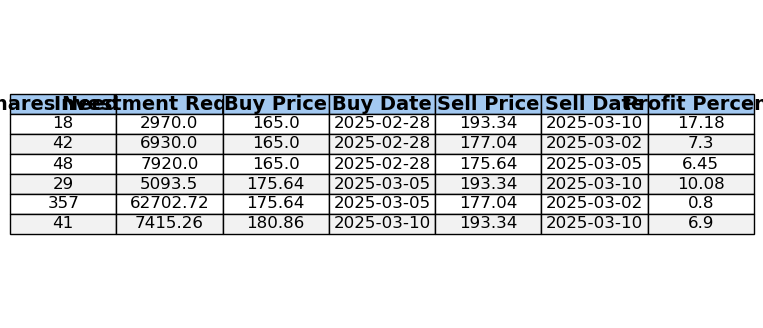

In [120]:
import matplotlib.pyplot as plt
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 4))

# Hide axes
ax.axis('off')

# Create the table
table_data = analysis_df[columns_to_show]
table = ax.table(cellText=table_data.values, colLabels=table_data.columns, loc='center', cellLoc='center', colColours=['#f5f5f5'] * len(table_data.columns))

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Add color to alternating rows
for i, key in enumerate(table.get_celld().keys()):
    cell = table.get_celld()[key]
    if key[0] == 0:
        cell.set_fontsize(14)
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#a3c9f1')  # Header row color
    elif key[0] % 2 == 0:
        cell.set_facecolor('#f2f2f2')  # Even row color
    else:
        cell.set_facecolor('#ffffff')  # Odd row color

# Show the plot
plt.show()

In [121]:
import matplotlib.pyplot as plt
from pandas.plotting import table

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))  # Adjust the size as needed

# Hide the axis
ax.axis('off')

# Render the DataFrame as a table
table(ax, analysis_df, loc='center', colWidths=[0.15]*len(analysis_df.columns))

# Save the figure as an image
plt.savefig(f'./images/{new_ticker}_styled_dataframe.png', bbox_inches='tight', dpi=300)
plt.close()

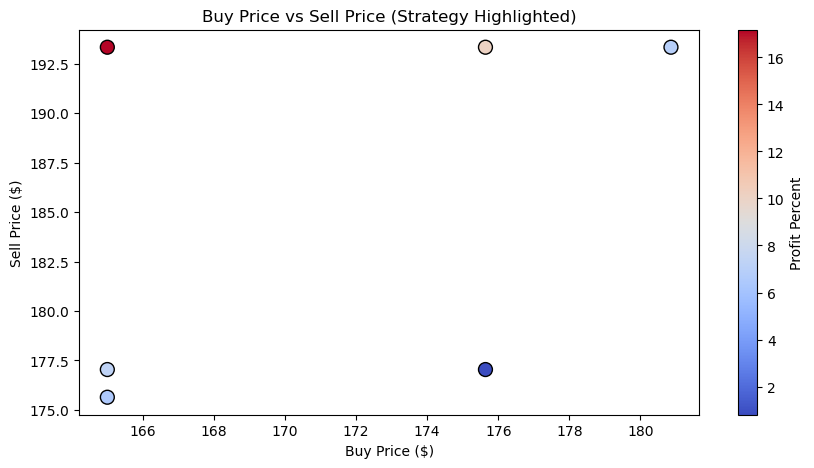

In [122]:
# Scatter plot for Buy Price vs Sell Price
fig, ax = plt.subplots(figsize=(10, 5))

# Plot Buy and Sell Prices
ax.scatter(analysis_df["Buy Price"], analysis_df["Sell Price"], c=analysis_df["Profit Percent"], cmap="coolwarm", edgecolors="k", s=100)
ax.set_xlabel("Buy Price ($)")
ax.set_ylabel("Sell Price ($)")
ax.set_title("Buy Price vs Sell Price (Strategy Highlighted)")

# Color bar for Profit Percent
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Profit Percent")

plt.show()


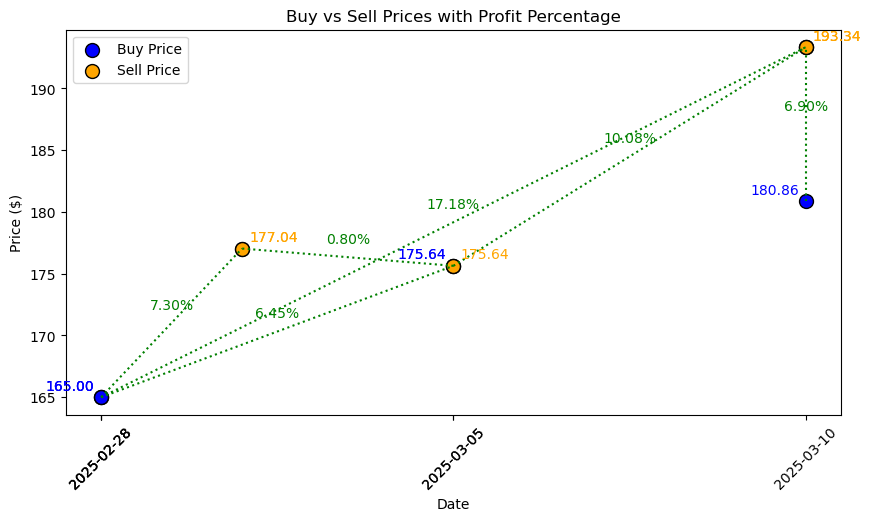

In [123]:
import matplotlib.pyplot as plt

# Convert Buy Date and Sell Date to ordinal (numeric) values
analysis_df["Buy Date Ordinal"] = analysis_df["Buy Date"].apply(lambda x: x.toordinal())
analysis_df["Sell Date Ordinal"] = analysis_df["Sell Date"].apply(lambda x: x.toordinal())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot Buy Prices (Blue Circles)
ax.scatter(analysis_df["Buy Date Ordinal"], analysis_df["Buy Price"], color="blue", label="Buy Price", s=100, edgecolors="black")

# Plot Sell Prices (Orange Circles)
ax.scatter(analysis_df["Sell Date Ordinal"], analysis_df["Sell Price"], color="orange", label="Sell Price", s=100, edgecolors="black")

# Connect Buy and Sell Prices with dotted lines
for i in range(len(analysis_df)):
    # Calculate Profit Percentage
    profit_percent = analysis_df["Profit Percent"].iloc[i]
    
    # Color the line based on Profit Percent
    line_color = "green" if profit_percent > 0 else "red"
    
    # Plot the dotted line with the corresponding color
    ax.plot([analysis_df["Buy Date Ordinal"].iloc[i], analysis_df["Sell Date Ordinal"].iloc[i]], 
            [analysis_df["Buy Price"].iloc[i], analysis_df["Sell Price"].iloc[i]], 
            linestyle="dotted", color=line_color)
    
    # Annotate Buy Price (Blue)
    ax.annotate(f'{analysis_df["Buy Price"].iloc[i]:.2f}', 
                (analysis_df["Buy Date Ordinal"].iloc[i], analysis_df["Buy Price"].iloc[i]), 
                textcoords="offset points", xytext=(-5, 5), ha='right', fontsize=10, color="blue")

    # Annotate Sell Price (Orange)
    ax.annotate(f'{analysis_df["Sell Price"].iloc[i]:.2f}', 
                (analysis_df["Sell Date Ordinal"].iloc[i], analysis_df["Sell Price"].iloc[i]), 
                textcoords="offset points", xytext=(5, 5), ha='left', fontsize=10, color="orange")
    
    # Annotate Profit Percentage with color based on profit
    profit_color = "green" if profit_percent > 0 else "red"
    ax.annotate(f'{profit_percent:.2f}%', 
                ((analysis_df["Buy Date Ordinal"].iloc[i] + analysis_df["Sell Date Ordinal"].iloc[i]) / 2, 
                 (analysis_df["Buy Price"].iloc[i] + analysis_df["Sell Price"].iloc[i]) / 2),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=profit_color)

# Labels and Title
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.set_title("Buy vs Sell Prices with Profit Percentage")

# Convert ordinal back to date format for x-axis
ax.set_xticks(analysis_df["Buy Date Ordinal"])
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in analysis_df["Buy Date"]], rotation=45)

# Show Legend
ax.legend()

# Display Plot
plt.show()
